In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pylab as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [2]:
auto_df=pd.read_csv(r"D:\ML Project1\Polynomial regretion\auto_islr_cleaned.csv")

In [3]:
auto_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,name
0,18,8,307,130,3504,12.0,American,chevrolet chevelle malibu
1,15,8,350,165,3693,11.5,American,buick skylark 320
2,18,8,318,150,3436,11.0,American,plymouth satellite
3,16,8,304,150,3433,12.0,American,amc rebel sst
4,17,8,302,140,3449,10.5,American,ford torino


In [4]:
auto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    int64  
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    int64  
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   origin        392 non-null    object 
 7   name          392 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 24.6+ KB


In [5]:
#remove name and origin
auto_df.drop(columns=["name","origin"],inplace=True)

In [6]:
auto_df

,mpg,cylinders,displacement,horsepower,weight,acceleration
0,18,8,307,130,3504,12.0
1,15,8,350,165,3693,11.5
2,18,8,318,150,3436,11.0
3,16,8,304,150,3433,12.0
4,17,8,302,140,3449,10.5
...,...,...,...,...,...,...
387,27,4,140,86,2790,15.6
388,44,4,97,52,2130,24.6
389,32,4,135,84,2295,11.6
390,28,4,120,79,2625,18.6


In [7]:
X_all_auto = auto_df.drop(columns=["mpg"])

In [8]:
y_auto = auto_df["mpg"]

In [9]:
X_train, X_test , y_train, y_test = train_test_split(X_all_auto, y_auto ,test_size=0.2,random_state=1)

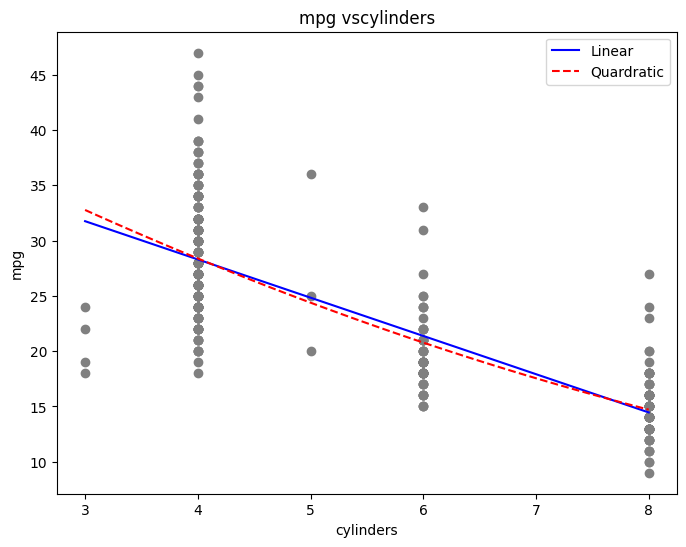

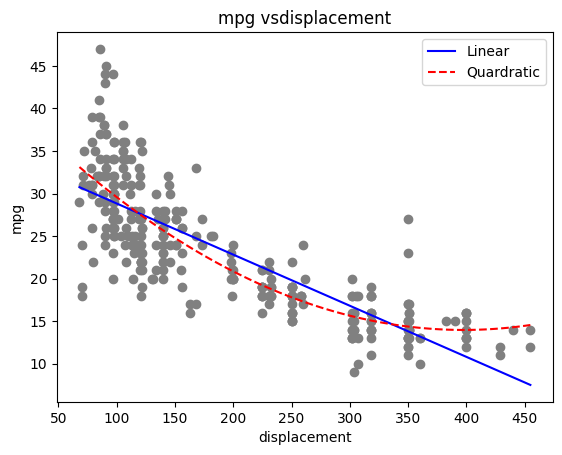

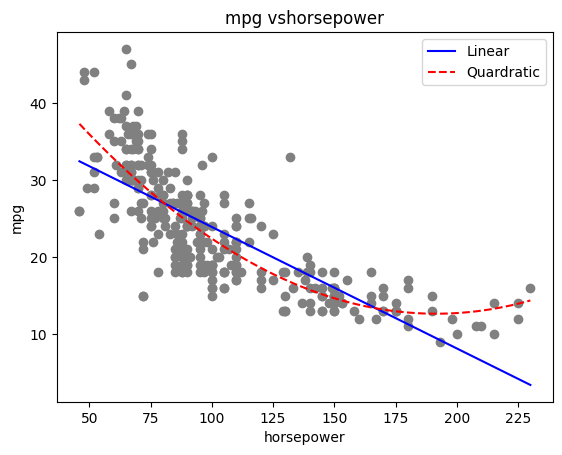

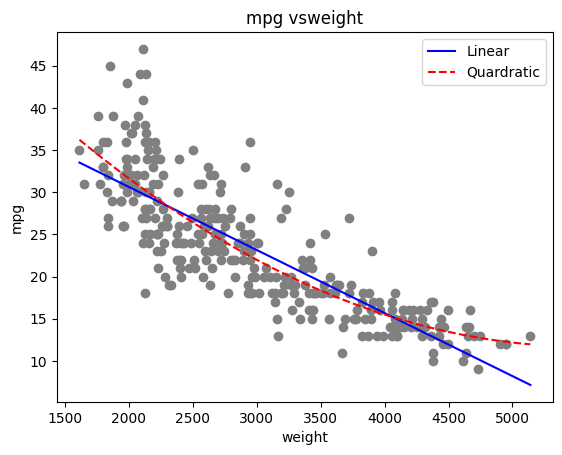

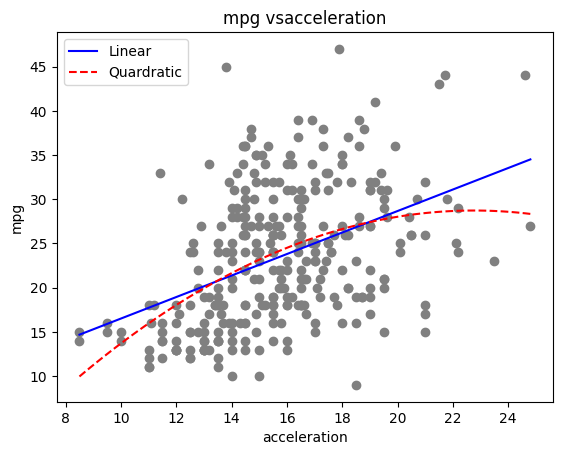

In [10]:
plt.figure(figsize=(8,6))
for col in X_train:
    X=np.array(X_train[col]).reshape(-1,1)
    y=y_train

    #fit linear equation
    lin = LinearRegression()
    lin.fit(X,y)

    #fit second degree poly
    second_deg_poly = LinearRegression()
    second_deg_poly.fit(np.c_[X,X**2],y)

    #genrate x-grid
    x_grid = np.linspace(X.min(),X.max(),100).reshape(-1,1)

    #predict with linear equation
    y_lin = lin.predict(x_grid)

    #prediction with second-deree poly
    y_quad = second_deg_poly.predict(np.c_[x_grid,x_grid**2])

    #scatter plot and curve
    plt.scatter(X,y,color="grey")
    plt.plot(x_grid,y_lin,'b-',label='Linear')
    plt.plot(x_grid,y_quad,'r--',label= 'Quardratic')
    plt.xlabel(col)
    plt.ylabel("mpg")
    plt.title("mpg vs"+col)
    plt.legend()
    plt.show()


In [11]:
poly_second_degree_pipeline = make_pipeline(PolynomialFeatures(degree=2),LinearRegression)

In [12]:
features_to_get_poly = ['displacement','horsepower','weight']

In [13]:
#create dataframe to  store cv result for each feature
poly_second_cv_df = pd.DataFrame(columns=['Predictor','Poly_Mean_CV_MSE'])


In [14]:
#the"cv_set_up" object desc how cross valuation takes place
cv_set_up = KFold(n_splits=10,shuffle=True,random_state=1)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_second_degree_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])


In [16]:
for i in features_to_get_poly:

    mse_scores_cv_poly = -cross_val_score(
        poly_second_degree_pipeline,
        X_train[[i]],      # keep 2D
        y_train,
        scoring="neg_mean_squared_error",
        cv=cv_set_up
    )

    mean_mse_poly = np.round(np.mean(mse_scores_cv_poly), 2)
    print(i, mean_mse_poly)

print(type(poly_second_degree_pipeline))  # must be Pipeline
print(type(X_train))                     # must be DataFrame
print(type(y_train))                     # Series or array


displacement 18.46
horsepower 18.89
weight 17.48
<class 'sklearn.pipeline.Pipeline'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [17]:
poly_second_degree_weight = poly_second_degree_pipeline.fit(X_train['weight'].values.reshape(-1,1), y_train)
poly_second_degree_weight

,steps,"[('poly', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [18]:
#Retreave the intersept using the intercept_ property
print( np.round(poly_second_degree_weight.named_steps['model'].intercept_,2))

60.45


In [19]:
#retreve the coefficient using the "coef_" property
print(poly_second_degree_weight.named_steps['model'].coef_)

[-1.75657955e-02  1.58258824e-06]


In [20]:
#prediction 
y_pred_poly_weight_test = poly_second_degree_weight.predict(X_test['weight'].values.reshape(-1,1))

In [21]:
#test RMSE
test_rmse = root_mean_squared_error(y_test , y_pred_poly_weight_test)
test_rmse = np.round(test_rmse , 2)
print(test_rmse)


4.28


In [22]:
mean_mpg = np.mean(y_auto)


In [23]:
coeff_variation = np.round( test_rmse / mean_mpg , 4)

In [24]:
print(coeff_variation)

0.1822


In [25]:
print(coeff_variation*100)

18.22


In [26]:
#store diffrent degree to try in a list
degree_to_test = [2,3,4]


In [27]:
# data frame to store cv results 
cv_for_diff_degrees_weiht_df = pd.DataFrame(columns=['Degree_Poly','Mean_CV_MSE'])

In [28]:
for i in degree_to_test:
    poly_loop_pipeline = make_pipeline(PolynomialFeatures(degree=i),LinearRegression())

    #cv for poly under consideration
    mse_scores_cv_poly =- cross_val_score(poly_loop_pipeline,X_train["weight"].values.reshape(-1,1),y_train, scoring='neg_mean_squared_error', cv = cv_set_up)
    mean_mse_poly = np.round(np.mean(mse_scores_cv_poly),2)

    cv_for_diff_degrees_weiht_df = pd.concat([cv_for_diff_degrees_weiht_df,pd.DataFrame({'Degree_Poly':i,'Mean_CV_MSE':[mean_mse_poly]})],ignore_index=True)

C:\Users\Aviral Goyal\AppData\Local\Temp\ipykernel_6584\2816261074.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cv_for_diff_degrees_weiht_df = pd.concat([cv_for_diff_degrees_weiht_df,pd.DataFrame({'Degree_Poly':i,'Mean_CV_MSE':[mean_mse_poly]})],ignore_index=True)


In [29]:
cv_for_diff_degrees_weiht_df

,Degree_Poly,Mean_CV_MSE
0,2,17.48
1,3,17.51
2,4,17.51
